# Mini Research #1: Bandpass Filtering for Exoplanet Transit SNR

## Research Question
**How does Butterworth bandpass filtering affect the signal-to-noise ratio (SNR) of an exoplanet transit light curve?**

## Objective
Investigate whether Butterworth bandpass filtering can reduce noise and improve transit detectability as measured by SNR.

## Hypothesis
Butterworth bandpass filtering will reduce unwanted noise and increase the measured SNR while preserving the transit signal.

## Method
- Dataset: Kepler-8, Kepler Quarter 5, short cadence
- Main comparison: Original vs. Butterworth-filtered light curve
- Main metric: SNR
- Supporting metrics: noise and transit depth


## 1. Install and Import Libraries


In [3]:
!pip install -q lightkurve scipy matplotlib numpy pandas


  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 2.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 261.1/261.1 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 96.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 206.6/206.6 kB 17.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 65.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.4/15.4 MB 89.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2026.7.0 which is incompatible.
datasets 4.0.0 

In [4]:
import lightkurve as lk
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.signal import butter, sosfiltfilt

print("Libraries imported successfully.")


Libraries imported successfully.


/usr/local/lib/python3.13/dist-packages/lightkurve/prf/__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(


## 2. Search for the Kepler-8 Dataset


In [5]:
search_result = lk.search_lightcurve(
    "Kepler-8",
    mission="Kepler"
)
search_result


#,mission,year,author,exptime,target_name,distance
,,,,s,,arcsec
0,Kepler Quarter 02,2009,Kepler,60,kplr006922244,0.0
1,Kepler Quarter 02,2009,Kepler,60,kplr006922244,0.0
2,Kepler Quarter 02,2009,Kepler,60,kplr006922244,0.0
3,Kepler Quarter 03,2009,Kepler,60,kplr006922244,0.0
4,Kepler Quarter 03,2009,Kepler,60,kplr006922244,0.0
5,Kepler Quarter 03,2009,Kepler,60,kplr006922244,0.0
6,Kepler Quarter 00,2009,Kepler,1800,kplr006922244,0.0
7,Kepler Quarter 01,2009,Kepler,1800,kplr006922244,0.0
8,Kepler Quarter 02,2009,Kepler,1800,kplr006922244,0.0


In [6]:
search_result.table


intentType,obs_collection,provenance_name,instrument_name,project,filters,wave_region,target_name,target_classification,obs_id,s_ra,s_dec,dataproduct_type,proposal_pi,calib_level,t_min,t_max,t_exptime,wavelength_region,em_min,em_max,obs_title,t_obs_release,proposal_id,proposal_type,sequence_number,s_region,jpegURL,dataURL,dataRights,mtFlag,srcDen,obsid,objID,wave_min,wave_max,objID1,distance,exptime,obsID,obs_collection_products,dataproduct_type_products,description,type,dataURI,productType,productGroupDescription,productSubGroupDescription,productDocumentationURL,project_products,prvversion,proposal_id_products,productFilename,size,parent_obsid,dataRights_products,calib_level_products,filters_products,author,mission,#,year,sort_order
,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,arcsec,s,,,,,,,,,,,,,,,,,,,,,,,,
str7,str6,str10,str17,str6,str6,str7,str28,str1,str68,float64,float64,str10,str23,int64,float64,float64,float64,str7,float64,float64,str18,float64,str3,str6,int64,str112,str115,str121,str6,bool,float64,str9,str9,float64,float64,str9,float64,float64,str9,str6,str10,str60,str1,str125,str9,str28,str8,str1,str10,str4,str3,str77,int64,str9,str6,int64,str6,str10,object,int64,int64,int64
science,Kepler,Kepler,Kepler,Kepler,KEPLER,OPTICAL,kplr006922244,--,kplr006922244_sc_Q003333310333330000,281.28811999999994,42.45108,timeseries,William Borucki,2,54953.0375,56423.50069444445,60.0,OPTICAL,418.4,905.0,Kepler Key Project,nan,EX,Kepler,--,POLYGON ICRS 281.28510846 42.45330200 281.28510867 42.44885800 281.29113133 42.44885800 281.29113154 42.45330200,http://archive.stsci.edu/missions/kepler/previews/0069/006922244/kplr006922244-2012121044856_slc_bw_large.png,http://archive.stsci.edu/missions/kepler/lightcurves/0069/006922244/kplr006922244_sc_Q003333310333330000.tar,PUBLIC,--,5885.0,602457,829335,418.4,905.0,829335,0.0,60,602457,Kepler,timeseries,Lightcurve Short Cadence (CSC) - Q2,C,mast:KEPLER/url/missions/kepler/lightcurves/0069/006922244/kplr006922244-2009201121230_slc.fits,SCIENCE,Minimum Recommended Products,SLC,--,Kepler,--,EX,kplr006922244-2009201121230_slc.fits,4550400,602457,PUBLIC,2,KEPLER,Kepler,Kepler Quarter 02,0,2009,1
science,Kepler,Kepler,Kepler,Kepler,KEPLER,OPTICAL,kplr006922244,--,kplr006922244_sc_Q003333310333330000,281.28811999999994,42.45108,timeseries,William Borucki,2,54953.0375,56423.50069444445,60.0,OPTICAL,418.4,905.0,Kepler Key Project,nan,EX,Kepler,--,POLYGON ICRS 281.28510846 42.45330200 281.28510867 42.44885800 281.29113133 42.44885800 281.29113154 42.45330200,http://archive.stsci.edu/missions/kepler/previews/0069/006922244/kplr006922244-2012121044856_slc_bw_large.png,http://archive.stsci.edu/missions/kepler/lightcurves/0069/006922244/kplr006922244_sc_Q003333310333330000.tar,PUBLIC,--,5885.0,602457,829335,418.4,905.0,829335,0.0,60,602457,Kepler,timeseries,Lightcurve Short Cadence (CSC) - Q2,C,mast:KEPLER/url/missions/kepler/lightcurves/0069/006922244/kplr006922244-2009231120729_slc.fits,SCIENCE,Minimum Recommended Products,SLC,--,Kepler,--,EX,kplr006922244-2009231120729_slc.fits,4432320,602457,PUBLIC,2,KEPLER,Kepler,Kepler Quarter 02,1,2009,1
science,Kepler,Kepler,Kepler,Kepler,KEPLER,OPTICAL,kplr006922244,--,kplr006922244_sc_Q003333310333330000,281.28811999999994,42.45108,timeseries,William Borucki,2,54953.0375,56423.50069444445,60.0,OPTICAL,418.4,905.0,Kepler Key Project,nan,EX,Kepler,--,POLYGON ICRS 281.28510846 42.45330200 281.28510867 42.44885800 281.29113133 42.44885800 281.29113154 42.45330200,http://archive.stsci.edu/missions/kepler/previews/0069/006922244/kplr006922244-2012121044856_slc_bw_large.png,http://archive.stsci.edu/missions/kepler/lightcurves/0069/006922244/kplr006922244_sc_Q003333310333330000.tar,PUBLIC,--,5885.0,602457,829335,418.4,905.0,829335,0.0,60,602457,Kepler,timeseries,Lightcurve Short Cadence (CSC) - Q2,C,mast:KEPLER/url/missions/kepler/lightcurves/0069/006922244/kplr006922244-2009259162342_slc.fits,SCIENCE,Minimum Recommended Products,SLC,--,Kepler,--,EX,kplr006922244-200925916234

## 3. Select Kepler Quarter 5 with 60-Second Cadence


In [7]:
selected = lk.search_lightcurve(
    "Kepler-8",
    mission="Kepler",
    quarter=5,
    exptime=60
)
selected


#,mission,year,author,exptime,target_name,distance
,,,,s,,arcsec
0,Kepler Quarter 05,2010,Kepler,60,kplr006922244,0.0
1,Kepler Quarter 05,2010,Kepler,60,kplr006922244,0.0
2,Kepler Quarter 05,2010,Kepler,60,kplr006922244,0.0


In [8]:
selected.table


intentType,obs_collection,provenance_name,instrument_name,project,filters,wave_region,target_name,target_classification,obs_id,s_ra,s_dec,dataproduct_type,proposal_pi,calib_level,t_min,t_max,t_exptime,wavelength_region,em_min,em_max,obs_title,t_obs_release,proposal_id,proposal_type,sequence_number,s_region,jpegURL,dataURL,dataRights,mtFlag,srcDen,obsid,objID,wave_min,wave_max,objID1,distance,exptime,obsID,obs_collection_products,dataproduct_type_products,description,type,dataURI,productType,productGroupDescription,productSubGroupDescription,productDocumentationURL,project_products,prvversion,proposal_id_products,productFilename,size,parent_obsid,dataRights_products,calib_level_products,filters_products,author,mission,#,year,sort_order
,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,arcsec,s,,,,,,,,,,,,,,,,,,,,,,,,
str7,str6,str10,str17,str6,str6,str7,str28,str1,str68,float64,float64,str10,str23,int64,float64,float64,float64,str7,float64,float64,str18,float64,str3,str6,int64,str112,str115,str121,str6,bool,float64,str9,str9,float64,float64,str9,float64,float64,str9,str6,str10,str60,str1,str125,str9,str28,str8,str1,str10,str4,str3,str77,int64,str9,str6,int64,str6,str10,object,int64,int64,int64
science,Kepler,Kepler,Kepler,Kepler,KEPLER,OPTICAL,kplr006922244,--,kplr006922244_sc_Q003333310333330000,281.28811999999994,42.45108,timeseries,William Borucki,2,54953.0375,56423.50069444445,60.0,OPTICAL,418.4,905.0,Kepler Key Project,nan,EX,Kepler,--,POLYGON ICRS 281.28510846 42.45330200 281.28510867 42.44885800 281.29113133 42.44885800 281.29113154 42.45330200,http://archive.stsci.edu/missions/kepler/previews/0069/006922244/kplr006922244-2012121044856_slc_bw_large.png,http://archive.stsci.edu/missions/kepler/lightcurves/0069/006922244/kplr006922244_sc_Q003333310333330000.tar,PUBLIC,--,5885.0,602457,829335,418.4,905.0,829335,0.0,60,602457,Kepler,timeseries,Lightcurve Short Cadence (CSC) - Q5,C,mast:KEPLER/url/missions/kepler/lightcurves/0069/006922244/kplr006922244-2010111051353_slc.fits,SCIENCE,Minimum Recommended Products,SLC,--,Kepler,--,EX,kplr006922244-2010111051353_slc.fits,4659840,602457,PUBLIC,2,KEPLER,Kepler,Kepler Quarter 05,0,2010,1
science,Kepler,Kepler,Kepler,Kepler,KEPLER,OPTICAL,kplr006922244,--,kplr006922244_sc_Q003333310333330000,281.28811999999994,42.45108,timeseries,William Borucki,2,54953.0375,56423.50069444445,60.0,OPTICAL,418.4,905.0,Kepler Key Project,nan,EX,Kepler,--,POLYGON ICRS 281.28510846 42.45330200 281.28510867 42.44885800 281.29113133 42.44885800 281.29113154 42.45330200,http://archive.stsci.edu/missions/kepler/previews/0069/006922244/kplr006922244-2012121044856_slc_bw_large.png,http://archive.stsci.edu/missions/kepler/lightcurves/0069/006922244/kplr006922244_sc_Q003333310333330000.tar,PUBLIC,--,5885.0,602457,829335,418.4,905.0,829335,0.0,60,602457,Kepler,timeseries,Lightcurve Short Cadence (CSC) - Q5,C,mast:KEPLER/url/missions/kepler/lightcurves/0069/006922244/kplr006922244-2010140023957_slc.fits,SCIENCE,Minimum Recommended Products,SLC,--,Kepler,--,EX,kplr006922244-2010140023957_slc.fits,4086720,602457,PUBLIC,2,KEPLER,Kepler,Kepler Quarter 05,1,2010,1
science,Kepler,Kepler,Kepler,Kepler,KEPLER,OPTICAL,kplr006922244,--,kplr006922244_sc_Q003333310333330000,281.28811999999994,42.45108,timeseries,William Borucki,2,54953.0375,56423.50069444445,60.0,OPTICAL,418.4,905.0,Kepler Key Project,nan,EX,Kepler,--,POLYGON ICRS 281.28510846 42.45330200 281.28510867 42.44885800 281.29113133 42.44885800 281.29113154 42.45330200,http://archive.stsci.edu/missions/kepler/previews/0069/006922244/kplr006922244-2012121044856_slc_bw_large.png,http://archive.stsci.edu/missions/kepler/lightcurves/0069/006922244/kplr006922244_sc_Q003333310333330000.tar,PUBLIC,--,5885.0,602457,829335,418.4,905.0,829335,0.0,60,602457,Kepler,timeseries,Lightcurve Short Cadence (CSC) - Q5,C,mast:KEPLER/url/missions/kepler/lightcurves/0069/006922244/kplr006922244-2010174090439_slc.fits,SCIENCE,Minimum Recommended Products,SLC,--,Kepler,--,EX,kplr006922244-201017409043

## 4. Download and Inspect the Light Curves


In [9]:
lc_collection = selected.download_all()
print(f"Number of downloaded light curves: {len(lc_collection)}")


Number of downloaded light curves: 3


In [10]:
for i, lc in enumerate(lc_collection):
    print(f"\nLight Curve {i}")
    print(f"Number of data points: {len(lc)}")
    print(f"Start time: {lc.time.min().value:.3f} days")
    print(f"End time: {lc.time.max().value:.3f} days")
    print(f"Time span: {(lc.time.max() - lc.time.min()).value:.3f} days")
    print(f"Median flux: {np.nanmedian(lc.flux.value):.6f}")



Light Curve 0
Number of data points: 46158
Start time: 443.481 days
End time: 475.011 days
Time span: 31.530 days
Median flux: 50590.226562

Light Curve 1
Number of data points: 40440
Start time: 476.278 days
End time: 503.905 days
Time span: 27.627 days
Median flux: 50138.726562

Light Curve 2
Number of data points: 49145
Start time: 504.600 days
End time: 538.173 days
Time span: 33.573 days
Median flux: 48950.859375


## 5. Visual Inspection of Raw Light Curves


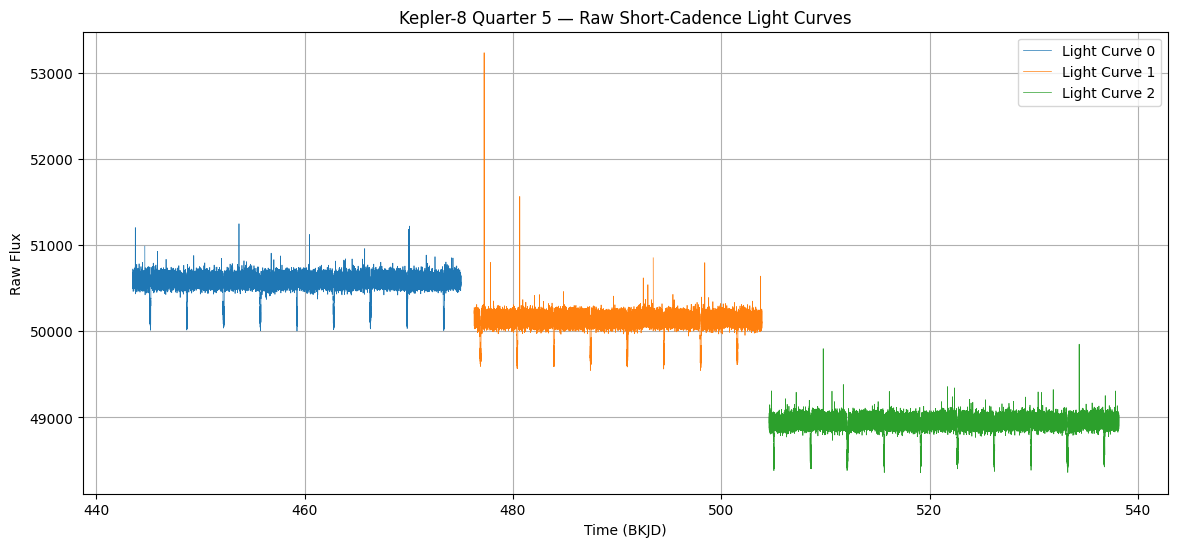

In [11]:
plt.figure(figsize=(14, 6))
for i, lc in enumerate(lc_collection):
    plt.plot(lc.time.value, lc.flux.value, linewidth=0.5, label=f"Light Curve {i}")
plt.xlabel("Time (BKJD)")
plt.ylabel("Raw Flux")
plt.title("Kepler-8 Quarter 5 — Raw Short-Cadence Light Curves")
plt.legend()
plt.grid(True)
plt.show()


## 6. Normalize the Light Curves


In [17]:
normalized_lcs = []
for lc in lc_collection:
    normalized_flux = lc.flux.value / np.nanmedian(lc.flux.value)
    normalized_lcs.append(normalized_flux)
print("Normalization completed.")


Normalization completed.


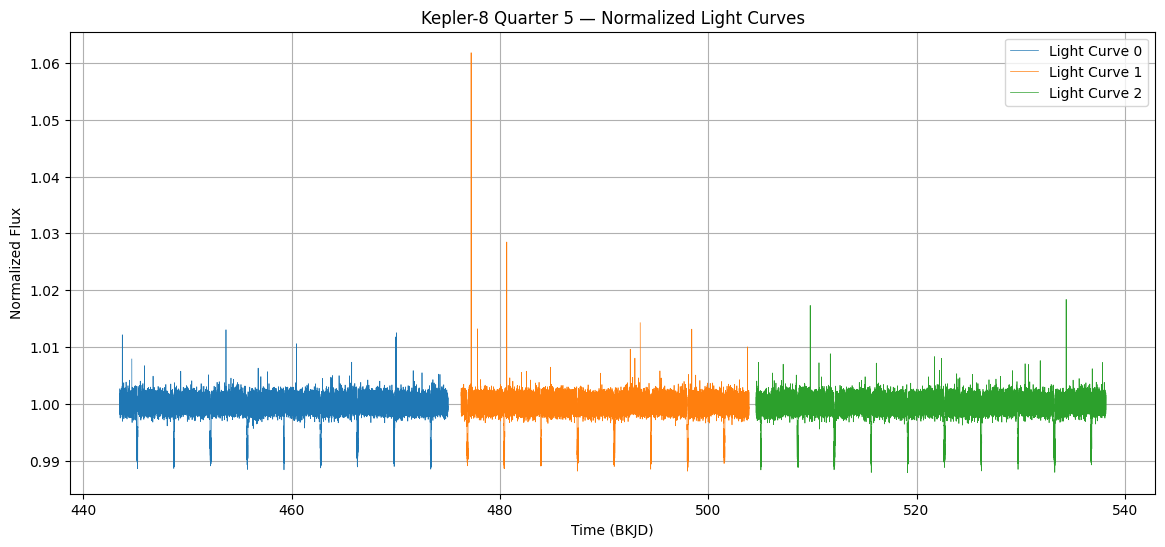

In [15]:
plt.figure(figsize=(14, 6))
for i, lc in enumerate(lc_collection):
    plt.plot(lc.time.value, normalized_lcs[i], linewidth=0.5, label=f"Light Curve {i}")
plt.xlabel("Time (BKJD)")
plt.ylabel("Normalized Flux")
plt.title("Kepler-8 Quarter 5 — Normalized Light Curves")
plt.legend()
plt.grid(True)
plt.show()


## 7. Check Cadence and Sampling Frequency


In [19]:
for i, lc in enumerate(lc_collection):
    time_values = lc.time.value
    dt = np.diff(time_values)
    normal_dt = dt[dt < np.percentile(dt, 95)]
    median_dt = np.median(normal_dt)
    print(f"Light Curve {i}")
    print(f"Median cadence: {median_dt * 24 * 60:.2f} minutes")
    print(f"Sampling frequency: {1 / median_dt:.2f} samples/day")
    print()


Light Curve 0
Median cadence: 0.98 minutes
Sampling frequency: 1468.15 samples/day

Light Curve 1
Median cadence: 0.98 minutes
Sampling frequency: 1468.15 samples/day

Light Curve 2
Median cadence: 0.98 minutes
Sampling frequency: 1468.17 samples/day



## 8. Compare Raw Scatter


In [18]:
for i, flux in enumerate(normalized_lcs):
    valid_flux = flux[np.isfinite(flux)]
    noise = np.std(valid_flux)
    print(f"Light Curve {i}")
    print(f"Standard deviation: {noise:.6f}")
    print(f"Approx. scatter: {noise * 1e6:.2f} ppm")
    print()


Light Curve 0
Standard deviation: 0.001767
Approx. scatter: 1766.72 ppm

Light Curve 1
Standard deviation: 0.001806
Approx. scatter: 1805.60 ppm

Light Curve 2
Standard deviation: 0.001807
Approx. scatter: 1806.52 ppm

Light Curve 0
Standard deviation: 0.001767
Approx. scatter: 1766.72 ppm

Light Curve 1
Standard deviation: 0.001806
Approx. scatter: 1805.60 ppm

Light Curve 2
Standard deviation: 0.001807
Approx. scatter: 1806.52 ppm



## 9. Inspect Individual Light Curves and Select the Analysis Segment


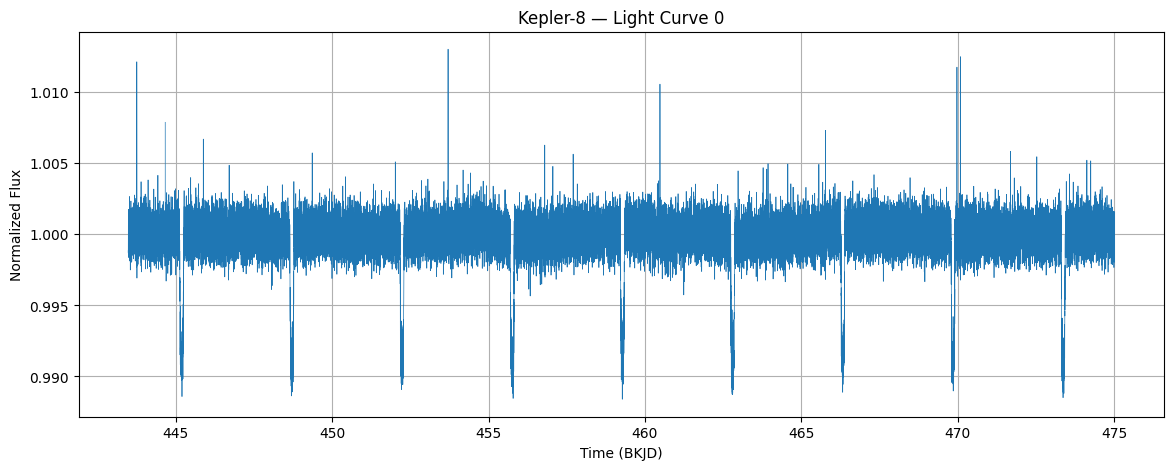

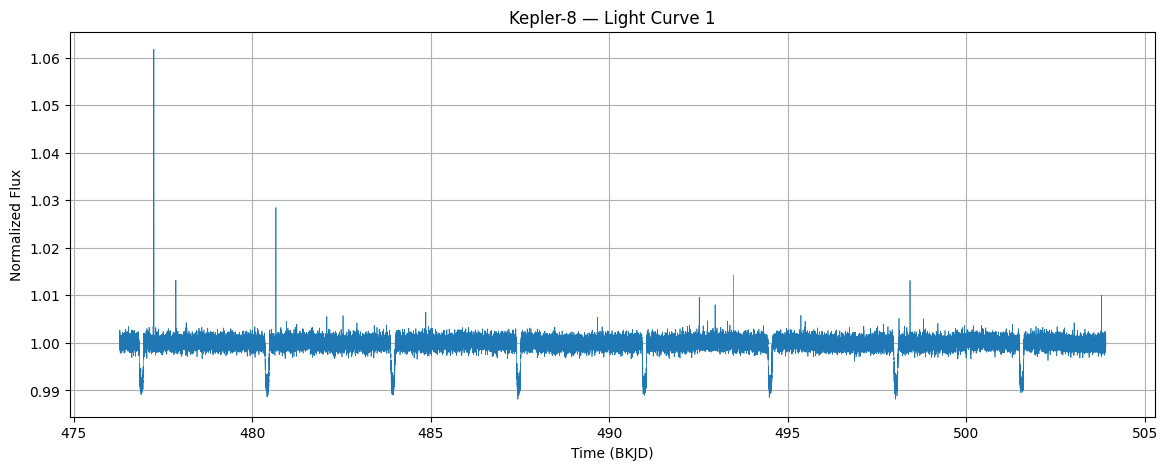

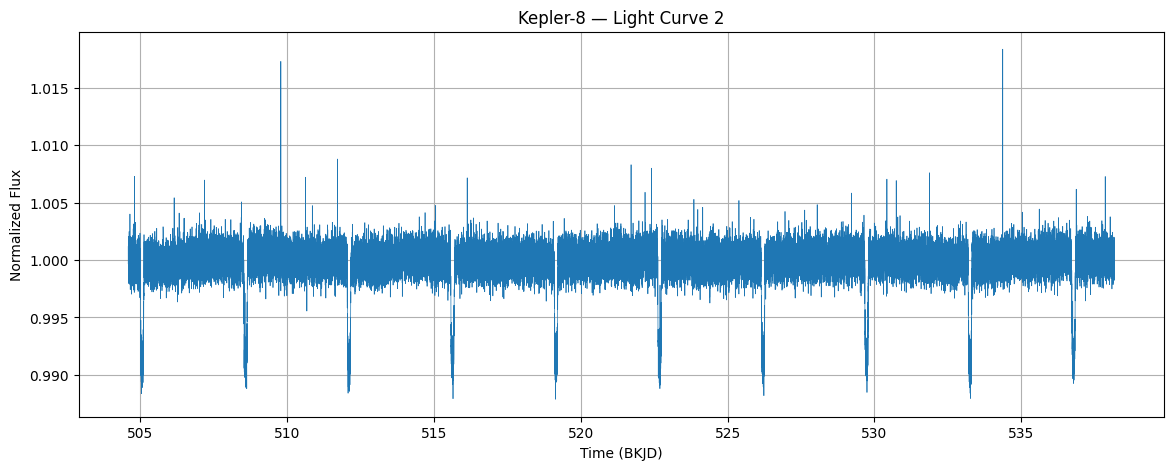

In [20]:
for i, lc in enumerate(lc_collection):
    plt.figure(figsize=(14, 5))
    plt.plot(lc.time.value, normalized_lcs[i], linewidth=0.5)
    plt.xlabel("Time (BKJD)")
    plt.ylabel("Normalized Flux")
    plt.title(f"Kepler-8 — Light Curve {i}")
    plt.grid(True)
    plt.show()


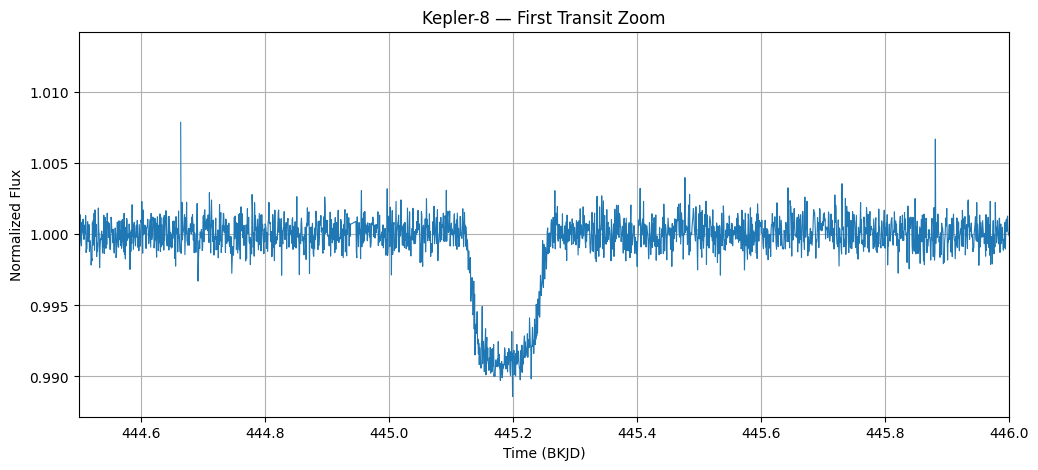

In [21]:
# Light Curve 0 is used for the main analysis because it provides
# a clean segment with clearly visible transit structure.
time0 = lc_collection[0].time.value
flux0 = normalized_lcs[0]

plt.figure(figsize=(12, 5))
plt.plot(time0, flux0, linewidth=0.8)
plt.xlim(444.5, 446.0)
plt.xlabel("Time (BKJD)")
plt.ylabel("Normalized Flux")
plt.title("Kepler-8 — First Transit Zoom")
plt.grid(True)
plt.show()


## 10. Define the Transit Region and Calculate Original SNR


In [22]:
transit_start = 445.12
transit_end = 445.26

in_transit = (time0 >= transit_start) & (time0 <= transit_end)
out_of_transit = ~in_transit

baseline_flux = np.median(flux0[out_of_transit])
transit_flux = np.median(flux0[in_transit])
signal_depth = baseline_flux - transit_flux
noise = np.std(flux0[out_of_transit])
snr = signal_depth / noise

print(f"Baseline flux: {baseline_flux:.6f}")
print(f"Transit flux: {transit_flux:.6f}")
print(f"Transit depth: {signal_depth:.6f}")
print(f"Transit depth: {signal_depth * 1e6:.2f} ppm")
print(f"Out-of-transit noise: {noise:.6f}")
print(f"Baseline SNR: {snr:.2f}")


Baseline flux: 1.000005
Transit flux: 0.992029
Transit depth: 0.007976
Transit depth: 7975.70 ppm
Out-of-transit noise: 0.001703
Baseline SNR: 4.68


## 11. Check and Clean Missing Values Before Filtering


In [23]:
flux0_float = np.asarray(flux0, dtype=np.float64)

print("Total data points:", len(flux0_float))
print("NaN values:", np.sum(np.isnan(flux0_float)))
print("Infinite values:", np.sum(np.isinf(flux0_float)))
print("Data type:", flux0_float.dtype)


Total data points: 46158
NaN values: 1
Infinite values: 0
Data type: float64


In [24]:
nan_indices = np.where(np.isnan(flux0_float))[0]
print("NaN indices:", nan_indices)
for idx in nan_indices:
    print(f"Time of NaN: {time0[idx]:.6f}")


NaN indices: [1736]
Time of NaN: 444.663484


In [25]:
flux_clean = flux0_float.copy()
nan_indices = np.where(np.isnan(flux_clean))[0]

for idx in nan_indices:
    flux_clean[idx] = np.interp(
        time0[idx],
        [time0[idx - 1], time0[idx + 1]],
        [flux_clean[idx - 1], flux_clean[idx + 1]]
    )

print("NaNs before cleaning:", np.sum(np.isnan(flux0_float)))
print("NaNs after cleaning:", np.sum(np.isnan(flux_clean)))
print("Cleaned data points:", len(flux_clean))


NaNs before cleaning: 1
NaNs after cleaning: 0
Cleaned data points: 46158


## 12. Design the Butterworth Bandpass Filter


In [26]:
dt = np.diff(time0)
normal_dt = dt[dt < np.percentile(dt, 95)]
median_dt = np.median(normal_dt)
fs = 1 / median_dt

lowcut = 0.1
highcut = 20.0
nyquist = 0.5 * fs

low = lowcut / nyquist
high = highcut / nyquist

sos = butter(
    N=3,
    Wn=[low, high],
    btype="bandpass",
    output="sos"
)

print("Butterworth filter designed successfully.")
print(f"Sampling frequency: {fs:.2f} samples/day")
print(f"Low cutoff: {lowcut} cycles/day")
print(f"High cutoff: {highcut} cycles/day")
print(f"Nyquist frequency: {nyquist:.2f} cycles/day")


Butterworth filter designed successfully.
Sampling frequency: 1468.15 samples/day
Low cutoff: 0.1 cycles/day
High cutoff: 20.0 cycles/day
Nyquist frequency: 734.08 cycles/day


## 13. Apply the Butterworth Filter


In [27]:
filtered_flux = sosfiltfilt(sos, flux_clean)

print("Butterworth SOS filter applied successfully.")
print("Filtered data points:", len(filtered_flux))
print("Filtered NaN values:", np.sum(np.isnan(filtered_flux)))
print("Filtered infinite values:", np.sum(np.isinf(filtered_flux)))


Butterworth SOS filter applied successfully.
Filtered data points: 46158
Filtered NaN values: 0
Filtered infinite values: 0


## 14. Calculate SNR After Filtering


In [28]:
filtered_in_transit = filtered_flux[in_transit]
filtered_out_of_transit = filtered_flux[out_of_transit]

filtered_baseline = np.median(filtered_out_of_transit)
filtered_transit = np.median(filtered_in_transit)
filtered_signal = filtered_baseline - filtered_transit
filtered_noise = np.std(filtered_out_of_transit)
filtered_snr = filtered_signal / filtered_noise

snr_improvement = ((filtered_snr - snr) / snr) * 100
noise_reduction = ((noise - filtered_noise) / noise) * 100

print(f"Original SNR: {snr:.2f}")
print(f"Filtered SNR: {filtered_snr:.2f}")
print(f"SNR Improvement: {snr_improvement:.2f}%")
print("\nDetailed measurements:")
print(f"Original signal depth: {signal_depth:.6f}")
print(f"Filtered signal depth: {filtered_signal:.6f}")
print(f"Original noise: {noise:.6f}")
print(f"Filtered noise: {filtered_noise:.6f}")
print(f"Noise reduction: {noise_reduction:.2f}%")


Original SNR: 4.68
Filtered SNR: 5.49
SNR Improvement: 17.20%

Detailed measurements:
Original signal depth: 0.007976
Filtered signal depth: 0.007819
Original noise: 0.001703
Filtered noise: 0.001425
Noise reduction: 16.35%


## 15. Visual Comparison: Original vs. Filtered


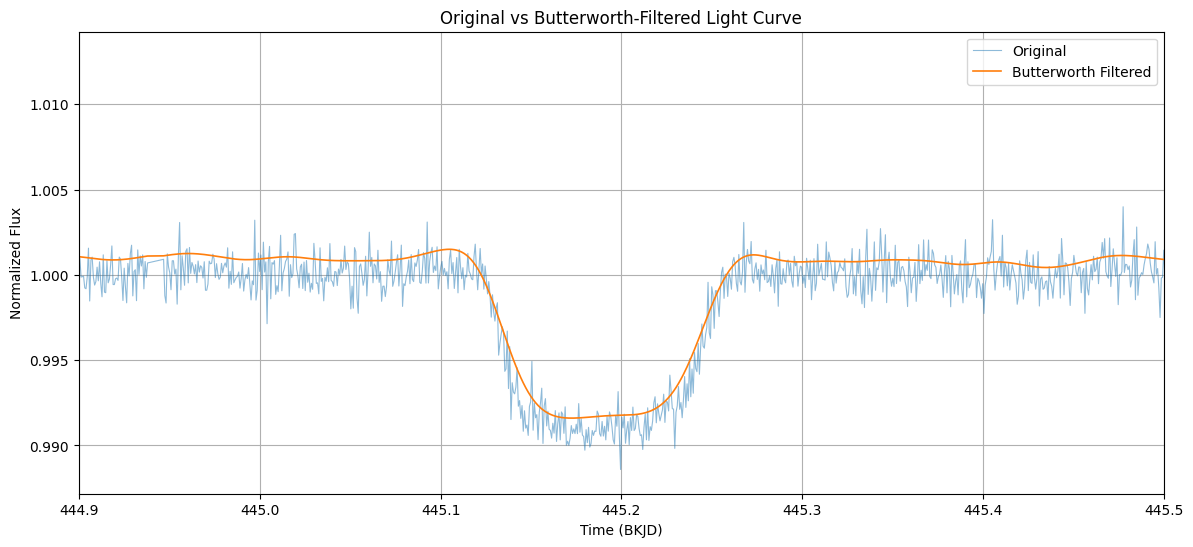

In [29]:
filtered_flux_plot = filtered_flux + np.median(flux_clean)

plt.figure(figsize=(14, 6))
plt.plot(time0, flux_clean, label="Original", alpha=0.5, linewidth=0.8)
plt.plot(time0, filtered_flux_plot, label="Butterworth Filtered", linewidth=1.2)
plt.xlim(444.9, 445.5)
plt.xlabel("Time (BKJD)")
plt.ylabel("Normalized Flux")
plt.title("Original vs Butterworth-Filtered Light Curve")
plt.legend()
plt.grid(True)
plt.show()


## 16. Final Results


In [30]:
results = {
    "Original SNR": snr,
    "Filtered SNR": filtered_snr,
    "SNR Improvement (%)": snr_improvement,
    "Original Signal Depth": signal_depth,
    "Filtered Signal Depth": filtered_signal,
    "Original Noise": noise,
    "Filtered Noise": filtered_noise,
    "Original Depth (ppm)": signal_depth * 1e6,
    "Filtered Depth (ppm)": filtered_signal * 1e6,
    "Original Data Points": len(flux_clean),
    "Filtered Data Points": len(filtered_flux),
    "Original NaNs": np.sum(np.isnan(flux_clean)),
    "Filtered NaNs": np.sum(np.isnan(filtered_flux)),
    "Filtered Infs": np.sum(np.isinf(filtered_flux))
}

for key, value in results.items():
    if isinstance(value, (float, np.floating)):
        print(f"{key}: {value:.6f}")
    else:
        print(f"{key}: {value}")


Original SNR: 4.682164192199707
Filtered SNR: 5.487545
SNR Improvement (%): 17.201037891051982
Original Signal Depth: 0.00797569751739502
Filtered Signal Depth: 0.007819
Original Noise: 0.0017034211196005344
Filtered Noise: 0.001425
Original Depth (ppm): 7975.69775390625
Filtered Depth (ppm): 7818.834386
Original Data Points: 46158
Filtered Data Points: 46158
Original NaNs: 0
Filtered NaNs: 0
Filtered Infs: 0


## 17. Interpretation


The Butterworth bandpass filter increased the measured SNR from approximately **4.68 to 5.49**, corresponding to an improvement of about **17.20%**.

The out-of-transit noise decreased by approximately **16.35%**, while the measured transit depth remained positive and close to its original value. For this selected Kepler-8 segment and these filter parameters, the filter therefore improved measured computational detectability.

This result does not by itself establish that the filter is astrophysically optimal or universally superior.


## 18. Validation


In [31]:
print("========== FINAL VALIDATION ==========")

print("\n[1] Data Integrity")
print("Original data points:", len(flux_clean))
print("Filtered data points:", len(filtered_flux))
print("Original NaNs:", np.sum(np.isnan(flux_clean)))
print("Filtered NaNs:", np.sum(np.isnan(filtered_flux)))
print("Filtered Infs:", np.sum(np.isinf(filtered_flux)))

print("\n[2] SNR Validation")
print(f"Original SNR: {snr:.4f}")
print(f"Filtered SNR: {filtered_snr:.4f}")
print(f"SNR Improvement: {snr_improvement:.2f}%")

print("\n[3] Signal / Noise Validation")
print(f"Original signal depth: {signal_depth:.6f}")
print(f"Filtered signal depth: {filtered_signal:.6f}")
print(f"Original noise: {noise:.6f}")
print(f"Filtered noise: {filtered_noise:.6f}")

print("\n[4] Noise Reduction")
print(f"Noise reduction: {noise_reduction:.2f}%")

print("\n[5] Transit Preservation")
print(f"Original transit depth: {signal_depth * 1e6:.2f} ppm")
print(f"Filtered transit depth: {filtered_signal * 1e6:.2f} ppm")

checks = {
    "Same number of data points": len(flux_clean) == len(filtered_flux),
    "No NaNs after cleaning": np.sum(np.isnan(flux_clean)) == 0,
    "No NaNs after filtering": np.sum(np.isnan(filtered_flux)) == 0,
    "No Infs after filtering": np.sum(np.isinf(filtered_flux)) == 0,
    "Filtered noise is lower": filtered_noise < noise,
    "Filtered SNR is higher": filtered_snr > snr,
    "Transit signal preserved": filtered_signal > 0
}

print("\n[6] Validation Checks")
for name, result in checks.items():
    status = "PASS" if result else "FAIL"
    print(f"{status}: {name}")

if all(checks.values()):
    print("\n====================================")
    print("FINAL VALIDATION: PASSED")
    print("The experiment is computationally consistent.")
    print("====================================")
else:
    print("\n====================================")
    print("FINAL VALIDATION: FAILED")
    print("Review the failed checks.")


========== FINAL VALIDATION ==========

[1] Data Integrity
Original data points: 46158
Filtered data points: 46158
Original NaNs: 0
Filtered NaNs: 0
Filtered Infs: 0

[2] SNR Validation
Original SNR: 4.6822
Filtered SNR: 5.4875
SNR Improvement: 17.20%

[3] Signal / Noise Validation
Original signal depth: 0.007976
Filtered signal depth: 0.007819
Original noise: 0.001703
Filtered noise: 0.001425

[4] Noise Reduction
Noise reduction: 16.35%

[5] Transit Preservation
Original transit depth: 7975.70 ppm
Filtered transit depth: 7818.83 ppm

[6] Validation Checks
PASS: Same number of data points
PASS: No NaNs after cleaning
PASS: No NaNs after filtering
PASS: No Infs after filtering
PASS: Filtered noise is lower
PASS: Filtered SNR is higher
PASS: Transit signal preserved

FINAL VALIDATION: PASSED
The experiment is computationally consistent.


## 19. Limitations


- The experiment uses one selected light curve segment and one transit window.
- The Butterworth cutoff frequencies were fixed for this experiment and were not optimized through a parameter sweep.
- The SNR definition is based on the selected transit and out-of-transit regions.
- The result measures computational improvement in this dataset; it is not a claim that Butterworth filtering is universally optimal.


## 20. Conclusion


For the selected Kepler-8 Quarter 5 light curve, Butterworth bandpass filtering reduced the measured out-of-transit noise and increased the calculated transit SNR from **4.68 to 5.49**, an improvement of **17.20%**.

Under the conditions of this experiment, the hypothesis is supported: the selected Butterworth filter improved the measured SNR while retaining a positive transit signal.


## 21. Final Research Figure


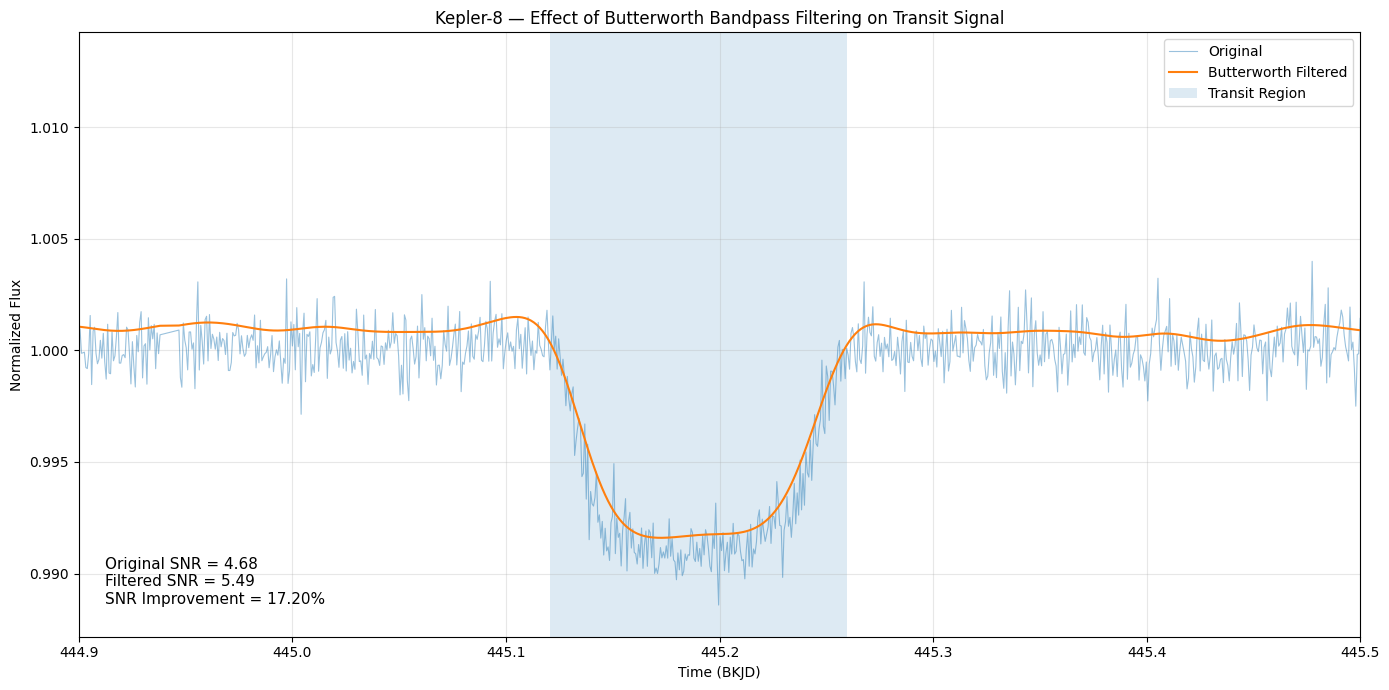

Final figure saved successfully.


In [32]:
plt.figure(figsize=(14, 7))

plt.plot(
    time0, flux_clean,
    label="Original",
    alpha=0.45,
    linewidth=0.8
)

plt.plot(
    time0, filtered_flux_plot,
    label="Butterworth Filtered",
    linewidth=1.5
)

transit_time = time0[in_transit]
if len(transit_time) > 0:
    plt.axvspan(
        transit_time.min(),
        transit_time.max(),
        alpha=0.15,
        label="Transit Region"
    )

plt.xlim(444.9, 445.5)
plt.xlabel("Time (BKJD)")
plt.ylabel("Normalized Flux")
plt.title("Kepler-8 — Effect of Butterworth Bandpass Filtering on Transit Signal")
plt.legend()

plt.text(
    0.02, 0.05,
    f"Original SNR = {snr:.2f}\n"
    f"Filtered SNR = {filtered_snr:.2f}\n"
    f"SNR Improvement = {snr_improvement:.2f}%",
    transform=plt.gca().transAxes,
    fontsize=11,
    verticalalignment="bottom"
)

plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    "final_butterworth_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
print("Final figure saved successfully.")


## 22. Save Final Results to CSV


In [33]:
final_results = pd.DataFrame({
    "Metric": [
        "Original SNR",
        "Filtered SNR",
        "SNR Improvement (%)",
        "Original Signal Depth",
        "Filtered Signal Depth",
        "Original Noise",
        "Filtered Noise",
        "Original Transit Depth (ppm)",
        "Filtered Transit Depth (ppm)",
        "Original Data Points",
        "Filtered Data Points"
    ],
    "Value": [
        snr,
        filtered_snr,
        snr_improvement,
        signal_depth,
        filtered_signal,
        noise,
        filtered_noise,
        signal_depth * 1e6,
        filtered_signal * 1e6,
        len(flux_clean),
        len(filtered_flux)
    ]
})

final_results.to_csv("final_results.csv", index=False)
print("Final results saved successfully.")


Final results saved successfully.
